# ChEMBL decoys — THRA / THRB binding analysis

Load the Rapposelli ChEMBL decoy set, standardize SMILES, score every ligand against
thyroid hormone receptors **THRA** and **THRB** with the 3-seed SOTA ensemble.

**Labels:** the parquet `binder` column is **THRB assay activity only** (ChEMBL experimental
actives/inactives + WS/Rapposelli subsets). There are no THRA ground-truth labels in this file.
Plot legends use **THRB binders** / **THRB nonbinders** (green / red); AUROC etc. are computed for **THRB** only.

**Convention:** `energy` = raw E from the FiLM energy head (lower = stronger binder).
EBM InfoNCE trains on `-E/T` logits, not projection dot products — those carry no signal here.
Ranking metrics on **THRB** only.

In [1]:
from __future__ import annotations

import argparse
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from rdkit import RDLogger
from scipy import stats
from sklearn.metrics import roc_curve
import os
REPO = Path("..").resolve()
NOTEBOOK_DIR = REPO / "notebooks"
os.chdir(REPO)
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from lattice_lab.eval.metrics import auroc, bedroc, ef_at_k
from lattice_lab.inference.predict import (
    build_encoder,
    build_head,
    encode_ligands,
    encode_protein,
    plot_violin,
    read_target_sequence,
)
from lattice_lab.preprocessing.molecules import inchikey_of, standardize_smiles

RDLogger.DisableLog("rdApp.*")
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(message)s")
%matplotlib inline

SOTA = REPO / "artifacts/sota/wk8denar"
HEAD_CKPTS = [
    SOTA / "ebm/seed0/ebm_best.ckpt",
    SOTA / "ebm/seed1/ebm_best.ckpt",
    SOTA / "ebm/seed2/ebm_best.ckpt",
]
PARQUET = NOTEBOOK_DIR / "chembl_decoys_ws1v1_ws1v2_rapposelli_slim.parquet"
FASTA_THRA = NOTEBOOK_DIR / "P10827-2_THA_HUMAN_Isoform_Alpha-1.fasta"
FASTA_THRB = NOTEBOOK_DIR / "P10828.fasta"
CACHE = REPO / "artifacts/predictions/chembl_decoys_thra_thrb_scores.parquet"
PLOT_DIR = REPO / "artifacts/predictions/chembl_decoys_thra_thrb_plots"

# ponytail: set MAX_ROWS to a small int for a quick smoke run; None = full set
MAX_ROWS: int | None = None
REFRESH_SCORES = False  # set True to re-run GPU scoring even if cache exists
COLUMN_MAP = {
    "smiles": "canonical_smiles",
    "is_binder": "binder",
    "source": "source",
    "id": "ivlid",
}
TARGETS = {"THRA": FASTA_THRA, "THRB": FASTA_THRB}
LABEL_TARGET = "THRB"  # parquet `binder` is THRB assay label — not valid for THRA metrics

for p in [*HEAD_CKPTS, PARQUET, FASTA_THRA, FASTA_THRB]:
    assert p.is_file(), f"missing: {p}"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"repo={REPO}  device={torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

repo=/pfs/lustrep4/scratch/project_465003063/benno/lattice_lab  device=AMD Instinct MI250X


In [2]:
raw = pd.read_parquet(PARQUET)
if MAX_ROWS is not None:
    raw = raw.head(MAX_ROWS).copy()
print(f"shape {raw.shape}")
print(raw.dtypes)
display(raw.head())
for c in raw.columns:
  if raw[c].nunique() <= 20:
    print(c, raw[c].value_counts().to_dict())

shape (8369, 5)
ivlid                 object
canonical_smiles      object
source                object
binder                  bool
p_activity_values    float64
dtype: object


,ivlid,canonical_smiles,source,binder,p_activity_values
0,3039405465294959a8ca8e1cece7a919,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CCC4=C3[C...,ChEMBL experimental,False,5.648
1,4d808a56f7fa25c669ee9bf5f6534eae,O=c1cnn(c2cc(Cl)c(Oc3ccc([O-])c(S(=O)(=O)n4ccc...,ChEMBL experimental,True,9.638
2,295b7e11ca2c6426d85ce17e825bb660,O=c1cnn(c2cc(Cl)c(Oc3ccc([O-])c(S(=O)(=O)Nc4cc...,ChEMBL experimental,True,9.550
3,e7ed219e66c2074336162edc1a60b138,CC(C)c1cc(Oc2c(Br)cc(CC(=O)N[C@H](C)C(=O)[O-])...,ChEMBL experimental,True,8.229
4,719f45ef9a946f4032cb5f408af7fc44,O=c1cnn(c2cc(Cl)c(Oc3ccc([O-])c(S(=O)(=O)N4CCc...,ChEMBL experimental,True,9.190


source {'Decoys': 7438, 'ChEMBL experimental': 713, 'WS1_v1': 110, 'WS1_v2': 104, 'Rapposelli': 4}
binder {False: 8012, True: 357}


In [3]:
df = raw.rename(columns={v: k for k, v in COLUMN_MAP.items()}).copy()
df["is_binder"] = df["is_binder"].astype(int)
df["smiles_std"] = df["smiles"].map(standardize_smiles)
df["valid"] = df["smiles_std"].notna()
df["inchikey"] = df["smiles_std"].map(lambda s: inchikey_of(s) if s else None)

n_bad = (~df["valid"]).sum()
print(f"invalid after standardize: {n_bad}/{len(df)}")
print("binder counts:", df["is_binder"].value_counts().to_dict())
print(f"NOTE: binder column is {LABEL_TARGET} assay label only — not THRA ground truth")
print("source counts:", df["source"].value_counts().to_dict())

dup = df.groupby(["inchikey", "is_binder"]).size()
n_dup_keys = int((dup > 1).sum())
print(f"duplicate inchikey+label groups: {n_dup_keys} (kept all rows)")
display(df.loc[df["valid"], ["smiles", "is_binder", "source", "p_activity_values"]].head())

invalid after standardize: 1/8369
binder counts: {0: 8012, 1: 357}
NOTE: binder column is THRB assay label only — not THRA ground truth
source counts: {'Decoys': 7438, 'ChEMBL experimental': 713, 'WS1_v1': 110, 'WS1_v2': 104, 'Rapposelli': 4}
duplicate inchikey+label groups: 43 (kept all rows)


,smiles,is_binder,source,p_activity_values
0,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=CC(=O)CCC4=C3[C...,0,ChEMBL experimental,5.648
1,O=c1cnn(c2cc(Cl)c(Oc3ccc([O-])c(S(=O)(=O)n4ccc...,1,ChEMBL experimental,9.638
2,O=c1cnn(c2cc(Cl)c(Oc3ccc([O-])c(S(=O)(=O)Nc4cc...,1,ChEMBL experimental,9.550
3,CC(C)c1cc(Oc2c(Br)cc(CC(=O)N[C@H](C)C(=O)[O-])...,1,ChEMBL experimental,8.229
4,O=c1cnn(c2cc(Cl)c(Oc3ccc([O-])c(S(=O)(=O)N4CCc...,1,ChEMBL experimental,9.190


In [4]:
def make_args() -> argparse.Namespace:
    device = "cuda" if torch.cuda.is_available() else "cpu"
    return argparse.Namespace(
        adapter_ckpt=HEAD_CKPTS[0],
        head_ckpt=HEAD_CKPTS[0],
        d_adapter=512,
        d_protein=1280,
        protein_backend="esm2",
        esm_model="facebook/esm2_t33_650M_UR50D",
        device=device,
        batch_size=256,
        n_views=4,
        n_jobs=1,
    )


from lattice_lab.inference.predict import score as head_energy


def score_set(args, encoder, heads, z_p, smiles: list[str], *, desc: str):
    """Mean ensemble energy per SMILES (NaN where unparseable)."""
    z_m, valid = encode_ligands(args, encoder, smiles, desc=desc)
    e = np.mean([head_energy(h, z_m, z_p, args) for h in heads], axis=0)
    full_e = np.full(len(smiles), np.nan, dtype=np.float32)
    full_e[np.array(valid, dtype=bool)] = e
    return full_e, valid


def load_models(args):
    encoder = build_encoder(args)
    args.d_adapter = encoder.adapter.d_adapter
    heads = []
    for ckpt in HEAD_CKPTS:
        args.head_ckpt = ckpt
        heads.append(build_head(args))
    return encoder, heads


def encode_targets(args):
    z_p = {}
    for name, fasta in TARGETS.items():
        seq = read_target_sequence(None, fasta)
        z_p[name] = encode_protein(args, seq)
        print(f"{name}: {len(seq)} residues -> z_p {z_p[name].shape}")
    return z_p

In [5]:
if CACHE.is_file() and not REFRESH_SCORES:
    pred_df = pd.read_parquet(CACHE).drop(columns=["score"], errors="ignore")
    print(f"loaded cached scores: {CACHE} ({len(pred_df)} rows)")
if not (CACHE.is_file() and not REFRESH_SCORES):
    args = make_args()
    encoder, heads = load_models(args)
    z_p = encode_targets(args)

    smiles = df["smiles_std"].fillna("").tolist()
    parts = []
    for target_name, zp in z_p.items():
        energy, valid = score_set(args, encoder, heads, zp, smiles, desc=target_name)
        part = df[["id", "smiles", "smiles_std", "inchikey", "is_binder", "source", "p_activity_values", "valid"]].copy()
        part["target"] = target_name
        part["energy"] = energy
        part["parse_ok"] = valid
        parts.append(part)
    pred_df = pd.concat(parts, ignore_index=True)
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    pred_df.to_parquet(CACHE, index=False)
    print(f"wrote {len(pred_df)} rows -> {CACHE}")

pred_df["rank_energy"] = pred_df.groupby("target")["energy"].rank(ascending=True, method="min")

display(pred_df.groupby(["target", "is_binder"]).agg(n=("energy", "size"), median_energy=("energy", "median")))

loaded cached scores: /pfs/lustrep4/scratch/project_465003063/benno/lattice_lab/artifacts/predictions/chembl_decoys_thra_thrb_scores.parquet (16738 rows)


n  median_energy
target is_binder                     
THRA   0          8012       0.761980
       1           357      -0.185525
THRB   0          8012       0.758080
       1           357      -0.118566

In [6]:
def _ranking_values(energy: np.ndarray) -> np.ndarray:
    """Map raw E to 'higher = binder' for metric helpers."""
    return -energy


def target_metrics(sub: pd.DataFrame) -> dict:
    ok = sub["valid"] & sub["parse_ok"] & sub["energy"].notna()
    s = sub.loc[ok]
    y = s["is_binder"].to_numpy(dtype=int)
    sc = _ranking_values(s["energy"].to_numpy(dtype=float))
    return {
        "n": int(len(s)),
        "n_binder": int(y.sum()),
        "auroc": auroc(y, sc),
        "bedroc": bedroc(y, sc, alpha=80.5),
        "ef@0.5%": ef_at_k(y, sc, 0.5),
        "ef@1%": ef_at_k(y, sc, 1.0),
        "ef@5%": ef_at_k(y, sc, 5.0),
    }


def binder_recall_at_pct(sub: pd.DataFrame, pct: float) -> float:
    ok = sub["valid"] & sub["parse_ok"] & sub["energy"].notna()
    s = sub.loc[ok].sort_values("energy", ascending=True)
    y = s["is_binder"].to_numpy(dtype=int)
    if y.sum() == 0:
        return float("nan")
    k = max(1, int(round(len(y) * pct / 100)))
    return float(y[:k].sum() / y.sum())


def _median_gap(sub: pd.DataFrame) -> float:
    ok = sub["valid"] & sub["parse_ok"] & sub["energy"].notna()
    s_ok = sub.loc[ok]
    bind = s_ok.loc[s_ok["is_binder"] == 1, "energy"]
    dec = s_ok.loc[s_ok["is_binder"] == 0, "energy"]
    if not len(bind) or not len(dec):
        return float("nan")
    return float(dec.median() - bind.median())


def _mannwhitney_p(sub: pd.DataFrame) -> float:
    ok = sub["valid"] & sub["parse_ok"] & sub["energy"].notna()
    s_ok = sub.loc[ok]
    bind = s_ok.loc[s_ok["is_binder"] == 1, "energy"]
    dec = s_ok.loc[s_ok["is_binder"] == 0, "energy"]
    if not len(bind) or not len(dec):
        return float("nan")
    return float(stats.mannwhitneyu(bind, dec, alternative="less").pvalue)


metrics_rows = []
for t in TARGETS:
    if t != LABEL_TARGET:
        continue
    sub = pred_df[pred_df["target"] == t]
    m = target_metrics(sub)
    m["target"] = t
    m["binder_recall@1%"] = binder_recall_at_pct(sub, 1.0)
    m["binder_recall@5%"] = binder_recall_at_pct(sub, 5.0)
    m["binder_recall@10%"] = binder_recall_at_pct(sub, 10.0)
    m["median_gap"] = _median_gap(sub)
    m["mannwhitney_p"] = _mannwhitney_p(sub)
    metrics_rows.append(m)

metrics_df = pd.DataFrame(metrics_rows).set_index("target")
display(metrics_df.round(4))

,n,n_binder,auroc,bedroc,ef@0.5%,ef@1%,ef@5%,binder_recall@1%,binder_recall@5%,binder_recall@10%,median_gap,mannwhitney_p
target,,,,,,,,,,,,
THRB,8368,357,0.7952,0.65,17.3008,17.0217,9.7572,0.1709,0.4874,0.6078,0.8766,0.0


### BindingDB val — in-batch cross-target retrieval

Same pairing logic as Stage-5 **cross-target** training: each batch row is a true binder `(z_m, z_p)`.
For ligand `i`, score against all `z_p` in the batch; the matched receptor (diagonal) is the only positive, all other batch receptors are negatives. No external decoy labels — mirrors the batch structure used during EBM training.

In [7]:
from lattice_lab.ebm.dataset import BinderDataset
from lattice_lab.protein.store import EmbeddingStore

BDB_VAL = REPO / "artifacts/preprocessing/processed/bindingdb/threshold_90/val.parquet"
PROTEIN_STORE_PATH = REPO / "artifacts/protein_store/embeddings/esm2_650M"
EVAL_BATCH_SIZE = 64
MAX_BATCHES = 50  # ponytail: subsample; raise or None for full val pass
INBATCH_SEED = 0

if "args" not in globals():
    args = make_args()
    encoder, heads = load_models(args)


@torch.no_grad()
def _batch_energy_matrix(z_m: np.ndarray, z_p: np.ndarray, heads) -> np.ndarray:
    """E[i,j] = mean ensemble energy of ligand i vs protein j (lower = better)."""
    b, dev = z_m.shape[0], args.device
    z_m_t = torch.from_numpy(z_m.astype(np.float32)).to(dev)
    z_p_t = torch.from_numpy(z_p.astype(np.float32)).to(dev)
    flat_m = z_m_t.unsqueeze(1).expand(b, b, -1).reshape(b * b, -1)
    e_sum = np.zeros((b, b), dtype=np.float64)
    for h in heads:
        flat_p = z_p_t.unsqueeze(0).expand(b, b, -1).reshape(b * b, -1)
        e_sum += h(flat_m, flat_p).reshape(b, b).cpu().numpy()
    return (e_sum / len(heads)).astype(np.float32)


def _inbatch_metrics(matrix: np.ndarray, *, higher_is_better: bool) -> dict[str, float]:
    b = matrix.shape[0]
    scores = matrix if higher_is_better else -matrix
    top1 = float((scores.argmax(axis=1) == np.arange(b)).mean())
    aucs = []
    for i in range(b):
        y = np.zeros(b, dtype=int)
        y[i] = 1
        aucs.append(auroc(y, scores[i]))
    return {"top1": top1, "auroc": float(np.mean(aucs)), "n_rows": b}


def eval_inbatch_split(name: str, parquet: Path, *, max_batches: int | None) -> list[dict]:
    store = EmbeddingStore.open(PROTEIN_STORE_PATH, mode="r")
    ds = BinderDataset(parquet, store, binders_only=True)
    rng = np.random.default_rng(INBATCH_SEED)
    perm = rng.permutation(len(ds))
    n_batches = len(perm) // EVAL_BATCH_SIZE
    if max_batches is not None:
        n_batches = min(n_batches, max_batches)

    rows: list[dict] = []
    for bi in range(n_batches):
        idx = perm[bi * EVAL_BATCH_SIZE : (bi + 1) * EVAL_BATCH_SIZE]
        smiles, uniprots = [], []
        for j in idx:
            row = ds[int(j)]
            smiles.append(row.smiles)
            uniprots.append(row.uniprot)
        z_m, _ = encode_ligands(args, encoder, smiles, desc=f"{name} b{bi}")
        if z_m.shape[0] != EVAL_BATCH_SIZE:
            continue
        z_p = np.stack([np.asarray(store.get_mean(u), dtype=np.float32) for u in uniprots])

        e_mat = _batch_energy_matrix(z_m, z_p, heads)
        m = _inbatch_metrics(e_mat, higher_is_better=False)
        rows.append({"split": name, "batch": bi, **m})
    return rows


inbatch_df = pd.DataFrame(eval_inbatch_split("val", BDB_VAL, max_batches=MAX_BATCHES))
summary = inbatch_df.groupby("split").agg(
    top1=("top1", "mean"), auroc=("auroc", "mean"), n_batches=("batch", "count"), n_rows=("n_rows", "sum"),
)
print(f"BindingDB in-batch cross-target retrieval  (batch={EVAL_BATCH_SIZE}, max_batches={MAX_BATCHES})")
display(summary.round(4))

INFO loading DDiT backbone + adapter (device=cuda)…


[DiscreteFlow] DDiT (fresh): 92.7M params, vocab=204, hidden=768, n_layer=12


/opt/miniconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
INFO loaded full encoder from /pfs/lustrep4/scratch/project_465003063/benno/lattice_lab/artifacts/sota/wk8denar/ebm/seed0/ebm_best.ckpt (layers 8-11, encode_time=0.9788)
INFO loaded energy head from /pfs/lustrep4/scratch/project_465003063/benno/lattice_lab/artifacts/sota/wk8denar/ebm/seed0/ebm_best.ckpt
INFO loaded energy head from /pfs/lustrep4/scratch/project_465003063/benno/lattice_lab/artifacts/sota/wk8denar/ebm/seed1/ebm_best.ckpt
INFO loaded energy head from /pfs/lustrep4/scratch/project_465003063/benno/lattice_lab/artifacts/sota/wk8denar/ebm/seed2/ebm_best.ckpt


fragmentize×4 [val b0]:   0%|          | 0/64 [00:00<?, ?mol/s]

encode z_m [val b0]:   0%|          | 0/1 [00:00<?, ?batch/s]

...

encode z_m [val b48]:   0%|          | 0/1 [00:00<?, ?batch/s]

fragmentize×4 [val b49]:   0%|          | 0/64 [00:00<?, ?mol/s]

encode z_m [val b49]:   0%|          | 0/1 [00:00<?, ?batch/s]

BindingDB in-batch cross-target retrieval  (batch=64, max_batches=50)


,top1,auroc,n_batches,n_rows
split,,,,
val,0.1141,0.7085,50,3200


### BindingDB train/val — binder vs decoy energy

Mirrors the Stage-5 EBM forward: `E(z_m⁺, z_p)` for each binder vs `N` decoy energies drawn from the hard-negative mix (MOSES + BDB cross-target binders + BDB non-binders), same as `training_step`.

**Temperature:** histograms plot **raw head output `E`**, matching `train/binder_e_mean` logged during training. InfoNCE uses logits `-E/T` (`T=0.1`) only inside the batch softmax — a uniform rescale that does not change ranking or the shape of these marginals. ChEMBL histograms below use the same raw `E` scale.

In [8]:
from lattice_lab.ebm.dataset import BinderDataset, DecoyZmPool, HardNegativeCollator, load_bdb_index, stack_z_p

BDB_TRAIN = REPO / "artifacts/preprocessing/processed/bindingdb/threshold_90/train.parquet"
DECOY_STORE = REPO / "artifacts/decoys/wk8denar/decoy_zm"
BDB_ZM_STORE = REPO / "artifacts/decoys/wk8denar/bdb_zm"
N_DECOYS = 64    # ponytail: training uses 600; lower here for notebook speed
EBM_BATCH_SIZE = 64
EBM_MAX_BATCHES = 30  # per split; raise for smoother curves

if "args" not in globals():
    args = make_args()
    encoder, heads = load_models(args)


N_OTHER = int(round(N_DECOYS * 0.4))
N_NON = int(round(N_DECOYS * 0.15))
N_RANDOM = N_DECOYS - N_OTHER - N_NON


def collect_binder_decoy_energies(name: str, parquet: Path, *, max_batches: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """binder_E + decoy E split by HardNegativeCollator pool (MOSES / BDB binders / BDB inactives)."""
    store = EmbeddingStore.open(PROTEIN_STORE_PATH, mode="r")
    coll = HardNegativeCollator.from_pools(
        DecoyZmPool.open(DECOY_STORE),
        DecoyZmPool.open(BDB_ZM_STORE),
        load_bdb_index(BDB_ZM_STORE),
        n_decoys=N_DECOYS,
        frac_other_binder=0.4,
        frac_non_binder=0.15,
        seed=INBATCH_SEED + (0 if name == "train" else 1),
    )
    ds = BinderDataset(parquet, store, binders_only=True)
    rng = np.random.default_rng(INBATCH_SEED + (0 if name == "train" else 1))
    perm = rng.permutation(len(ds))
    n_batches = min(len(perm) // EBM_BATCH_SIZE, max_batches)

    bind_e, rand_e, other_e, non_e = [], [], [], []
    n_r, n_o, n_n = coll.n_random, coll.n_other, coll.n_non
    for bi in range(n_batches):
        idx = perm[bi * EBM_BATCH_SIZE : (bi + 1) * EBM_BATCH_SIZE]
        batch = coll([ds[int(j)] for j in idx])
        z_m, _ = encode_ligands(args, encoder, batch.binder_smiles, desc=f"{name} b{bi}")
        if z_m.shape[0] != EBM_BATCH_SIZE:
            continue
        z_p = stack_z_p(batch.uniprots, store, args.device)
        z_m_t = torch.from_numpy(z_m.astype(np.float32)).to(args.device)
        z_m_dec = batch.decoy_z_m.to(args.device)
        n = z_m_dec.shape[1]
        with torch.no_grad():
            e_pos = np.zeros(EBM_BATCH_SIZE, dtype=np.float64)
            e_dec = np.zeros((EBM_BATCH_SIZE, n), dtype=np.float64)
            z_p_dec = z_p.unsqueeze(1).expand(-1, n, -1)
            for h in heads:
                e_pos += h(z_m_t, z_p).cpu().numpy()
                e_dec += h(z_m_dec, z_p_dec).cpu().numpy()
            e_pos /= len(heads)
            e_dec /= len(heads)
        dec = e_dec.astype(np.float32)
        bind_e.append(e_pos.astype(np.float32))
        off = 0
        if n_r:
            rand_e.append(dec[:, off : off + n_r].reshape(-1))
            off += n_r
        if n_o:
            other_e.append(dec[:, off : off + n_o].reshape(-1))
            off += n_o
        if n_n:
            non_e.append(dec[:, off : off + n_n].reshape(-1))
    out = tuple(np.concatenate(x) if x else np.array([], dtype=np.float32) for x in (bind_e, rand_e, other_e, non_e))
    return out  # type: ignore[return-value]


train_bind, train_rand, train_other, train_non = collect_binder_decoy_energies("train", BDB_TRAIN, max_batches=EBM_MAX_BATCHES)
val_bind, val_rand, val_other, val_non = collect_binder_decoy_energies("val", BDB_VAL, max_batches=EBM_MAX_BATCHES)
train_dec = np.concatenate([train_rand, train_other, train_non])
val_dec = np.concatenate([val_rand, val_other, val_non])
print(f"pools/batch: MOSES={N_RANDOM}  BDB other-target={N_OTHER}  BDB non-binder={N_NON}")
print(f"train binder median={np.median(train_bind):.3f}  decoy median={np.median(train_dec):.3f}")
print(f"val   binder median={np.median(val_bind):.3f}  decoy median={np.median(val_dec):.3f}")

fragmentize×4 [train b0]:   0%|          | 0/64 [00:00<?, ?mol/s]

encode z_m [train b0]:   0%|          | 0/1 [00:00<?, ?batch/s]

fragmentize×4 [train b1]:   0%|          | 0/64 [00:00<?, ?mol/s]

encode z_m [train b1]:   0%|          | 0/1 [00:00<?, ?batch/s]

fragmentize×4 [train b2]:   0%|          | 0/64 [00:00<?, ?mol/s]

...

fragmentize×4 [val b28]:   0%|          | 0/64 [00:00<?, ?mol/s]

encode z_m [val b28]:   0%|          | 0/1 [00:00<?, ?batch/s]

fragmentize×4 [val b29]:   0%|          | 0/64 [00:00<?, ?mol/s]

encode z_m [val b29]:   0%|          | 0/1 [00:00<?, ?batch/s]

pools/batch: MOSES=28  BDB other-target=26  BDB non-binder=10
train binder median=-0.639  decoy median=1.345
val   binder median=0.726  decoy median=1.242


global energy x: [-10.115, 5.697]


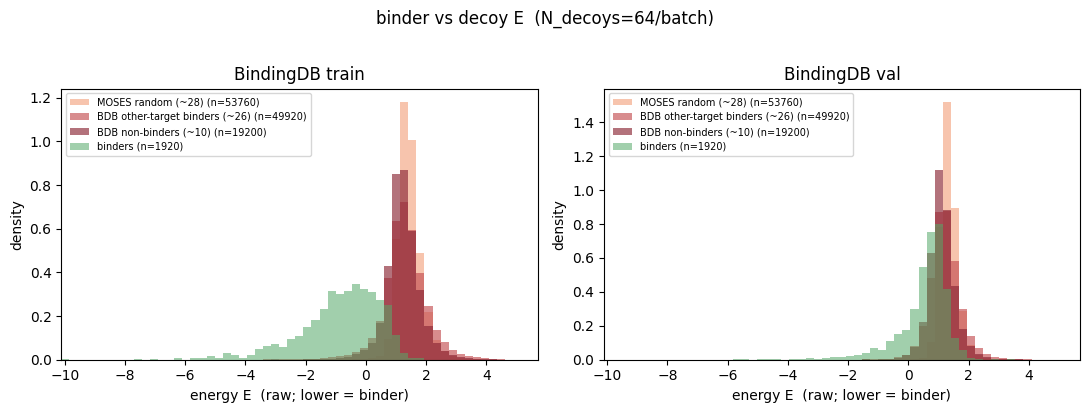

saved /pfs/lustrep4/scratch/project_465003063/benno/lattice_lab/artifacts/predictions/chembl_decoys_thra_thrb_plots/bdb_train_val_energy.png


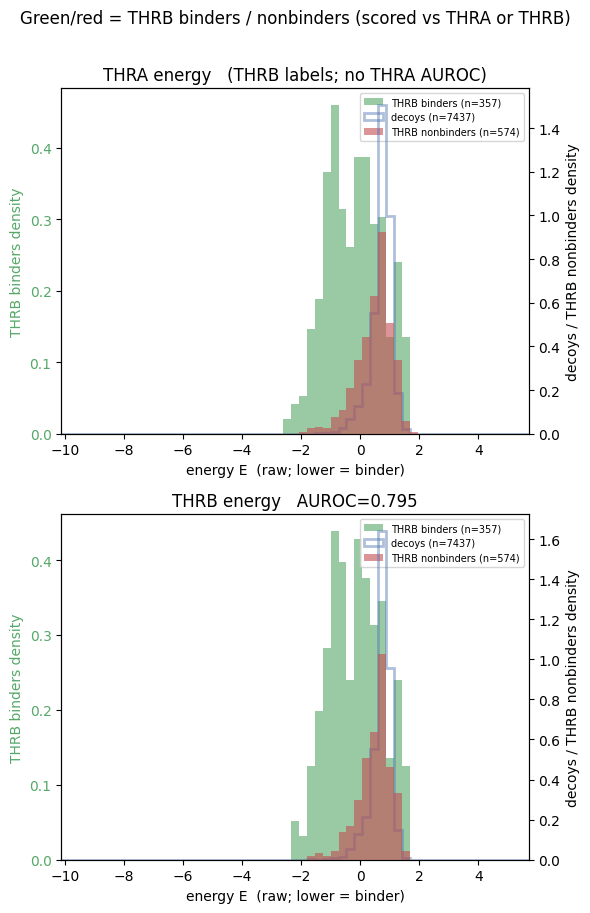

metrics:


,n,n_binder,auroc,bedroc,ef@0.5%,ef@1%,ef@5%,binder_recall@1%,binder_recall@5%,binder_recall@10%,median_gap,mannwhitney_p
target,,,,,,,,,,,,
THRB,8368,357,0.7952,0.65,17.3008,17.0217,9.7572,0.1709,0.4874,0.6078,0.8766,0.0


In [9]:
BINDER, DECOY, NONBINDER = "#55A868", "#4C72B0", "#C44E52"  # green / blue / red
BINDER_LBL, NONBINDER_LBL = "THRB binders", "THRB nonbinders"
N_BINS = 60
DECOY_SOURCE = "Decoys"
SOURCE_ORDER = [
    ("ChEMBL experimental", "ChEMBL actives", "chembl_actives"),
    ("WS1_v1", "Workstream 1", "nonbinder"),
    ("WS1_v2", "Workstream 2", "nonbinder"),
    ("Rapposelli", "Rapposelli", "nonbinder"),
]


def _is_label_target(target_name: str) -> bool:
    return target_name == LABEL_TARGET


def _valid_sub(target_name: str) -> pd.DataFrame:
    sub = pred_df[pred_df["target"] == target_name]
    ok = sub["valid"] & sub["parse_ok"] & sub["energy"].notna()
    return sub.loc[ok]


def _finite_concat(*arrays: np.ndarray) -> np.ndarray:
    parts = [a[np.isfinite(a)] for a in arrays if a.size]
    return np.concatenate(parts) if parts else np.array([])


def _bins_from_range(lo: float, hi: float) -> np.ndarray:
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        pad = 1e-3 if lo == hi else 1.0
        return np.linspace((lo or 0) - pad, (hi or 1) + pad, N_BINS)
    return np.linspace(lo, hi, N_BINS)


en = _finite_concat(
    *[_valid_sub(t)["energy"].to_numpy() for t in TARGETS],
    train_bind, train_rand, train_other, train_non,
    val_bind, val_rand, val_other, val_non,
)
ENERGY_BINS = _bins_from_range(en.min(), en.max())
ENERGY_XLIM = (float(ENERGY_BINS[0]), float(ENERGY_BINS[-1]))

DECOY_REF = {t: _valid_sub(t).loc[_valid_sub(t)["source"] == DECOY_SOURCE, "energy"].to_numpy() for t in TARGETS}


def _add_decoy_ref(ax, dec_ref: np.ndarray, bins: np.ndarray, *, show: bool = True) -> None:
    """Blue step histogram of property-matched decoys (reference on every panel)."""
    if not show:
        return
    dec_ref = dec_ref[np.isfinite(dec_ref)]
    if not dec_ref.size:
        return
    ax.hist(
        dec_ref, bins=bins, alpha=0.35, density=True, color=DECOY,
        histtype="step", linewidth=2, label=f"decoys ref (n={dec_ref.size})", zorder=1,
    )


def _legend(ax, *extra_axes) -> None:
    h, l = ax.get_legend_handles_labels()
    for ax_e in extra_axes:
        h2, l2 = ax_e.get_legend_handles_labels()
        h, l = h + h2, l + l2
    if h:
        ax.legend(h, l, fontsize=7, loc="upper right")


def _shared_bins(*arrays: np.ndarray) -> np.ndarray:
    v = _finite_concat(*arrays)
    return _bins_from_range(v.min(), v.max()) if v.size else ENERGY_BINS


def _hist_twin(
    ax,
    left: np.ndarray,
    right: np.ndarray,
    *,
    bins: np.ndarray,
    xlim: tuple[float, float],
    left_label: str,
    right_label: str,
    left_color: str,
    right_color: str,
    xlabel: str,
    title: str,
    dec_ref: np.ndarray | None = None,
    show_dec_ref: bool = True,
) -> None:
    left = left[np.isfinite(left)]
    right = right[np.isfinite(right)]
    ax_r = None
    if right.size or (show_dec_ref and dec_ref is not None and np.isfinite(dec_ref).any()):
        ax_r = ax.twinx()
        _add_decoy_ref(ax_r, dec_ref if dec_ref is not None else np.array([]), bins, show=show_dec_ref)
    if left.size:
        ax.hist(left, bins=bins, alpha=0.6, density=True, color=left_color, label=f"{left_label} (n={left.size})", zorder=3)
        ax.set_ylabel(f"{left_label} density", color=left_color)
        ax.tick_params(axis="y", labelcolor=left_color)
    if right.size and ax_r is not None:
        ax_r.hist(right, bins=bins, alpha=0.6, density=True, color=right_color, label=f"{right_label} (n={right.size})", zorder=2)
        ax_r.set_ylabel(f"{right_label} density", color=right_color)
        ax_r.tick_params(axis="y", labelcolor=right_color)
    elif ax_r is not None and show_dec_ref:
        ax_r.set_ylabel("decoys ref density", color=DECOY)
        ax_r.tick_params(axis="y", labelcolor=DECOY)
    if not left.size and not right.size and not (show_dec_ref and dec_ref is not None and np.isfinite(dec_ref).any()):
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
    _legend(ax, *( [ax_r] if ax_r is not None else [] ))
    ax.set_xlim(*xlim)
    ax.set_xlabel(xlabel)
    ax.set_title(title)


def _split_classes(s: pd.DataFrame, val: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    bind = s.loc[s["is_binder"] == 1, val].to_numpy()
    dec = s.loc[(s["is_binder"] == 0) & (s["source"] == DECOY_SOURCE), val].to_numpy()
    non = s.loc[(s["is_binder"] == 0) & (s["source"] != DECOY_SOURCE), val].to_numpy()
    return bind, dec, non


def _hist_three(ax, bind, dec, non, *, bins: np.ndarray, xlim: tuple[float, float], xlabel: str, title: str) -> None:
    bind, dec, non = bind[np.isfinite(bind)], dec[np.isfinite(dec)], non[np.isfinite(non)]
    if not (bind.size or dec.size or non.size):
        ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        ax.set_xlim(*xlim)
        return
    if bind.size:
        ax.hist(bind, bins=bins, alpha=0.6, density=True, color=BINDER, label=f"{BINDER_LBL} (n={bind.size})", zorder=3)
        ax.set_ylabel(f"{BINDER_LBL} density", color=BINDER)
        ax.tick_params(axis="y", labelcolor=BINDER)
    ax_r = ax.twinx()
    if dec.size:
        ax_r.hist(dec, bins=bins, alpha=0.45, density=True, color=DECOY, histtype="step", linewidth=2, label=f"decoys (n={dec.size})", zorder=1)
    if non.size:
        ax_r.hist(non, bins=bins, alpha=0.6, density=True, color=NONBINDER, label=f"{NONBINDER_LBL} (n={non.size})", zorder=2)
    ax_r.set_ylabel(f"decoys / {NONBINDER_LBL} density")
    _legend(ax, ax_r)
    ax.set_xlim(*xlim)
    ax.set_xlabel(xlabel)
    ax.set_title(title)


DECOY_POOLS = [
    (f"MOSES random (~{N_RANDOM})", "#F4A582"),           # drug-like decoys
    (f"BDB other-target binders (~{N_OTHER})", "#C44E52"),  # binders to other proteins
    (f"BDB non-binders (~{N_NON})", "#8B2635"),         # annotated inactives
]

print(f"global energy x: [{ENERGY_XLIM[0]:.3f}, {ENERGY_XLIM[1]:.3f}]")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, title, b, dr, do, dn in zip(
    axes,
    ("train", "val"),
    (train_bind, val_bind),
    (train_rand, val_rand),
    (train_other, val_other),
    (train_non, val_non),
):
    for d, (lbl, color) in zip((dr, do, dn), DECOY_POOLS):
        if d.size:
            ax.hist(d, bins=ENERGY_BINS, density=True, alpha=0.65, color=color, label=f"{lbl} (n={d.size})")
    ax.hist(b, bins=ENERGY_BINS, density=True, alpha=0.55, color=BINDER, label=f"binders (n={b.size})")
    ax.set_xlim(*ENERGY_XLIM)
    ax.set_title(f"BindingDB {title}")
    ax.set_xlabel("energy E  (raw; lower = binder)")
    ax.set_ylabel("density")
    ax.legend(fontsize=7)
fig.suptitle(f"binder vs decoy E  (N_decoys={N_DECOYS}/batch)", y=1.02)
fig.tight_layout()
bdb_out = PLOT_DIR / "bdb_train_val_energy.png"
fig.savefig(bdb_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {bdb_out}")

fig, axes = plt.subplots(len(TARGETS), 1, figsize=(6, 4.5 * len(TARGETS)), squeeze=False)

for row, target_name in enumerate(TARGETS):
    s = _valid_sub(target_name)
    b_en, d_en, n_en = _split_classes(s, "energy")
    if _is_label_target(target_name):
        y = s["is_binder"].to_numpy(dtype=int)
        en = s["energy"].to_numpy(dtype=float)
        en_title = f"{target_name} energy   AUROC={auroc(y, -en):.3f}"
    else:
        en_title = f"{target_name} energy   (THRB labels; no THRA AUROC)"
    _hist_three(axes[row, 0], b_en, d_en, n_en, bins=ENERGY_BINS, xlim=ENERGY_XLIM, xlabel="energy E  (raw; lower = binder)", title=en_title)

fig.suptitle("Green/red = THRB binders / nonbinders (scored vs THRA or THRB)", y=1.01)
fig.tight_layout()
fig.savefig(PLOT_DIR / "binder_decoy_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("metrics:")
display(metrics_df.round(4))

In [10]:
fig, axes = plt.subplots(1, len(TARGETS), figsize=(5 * len(TARGETS), 4), squeeze=False)

for ax, target_name in zip(axes[0], TARGETS):
    s = _valid_sub(target_name)
    if not _is_label_target(target_name):
        ax.text(0.5, 0.5, "no THRA labels\nin parquet", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{target_name} ROC")
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        continue
    y = s["is_binder"].to_numpy(dtype=int)
    en = s["energy"].to_numpy(dtype=float)
    fpr_e, tpr_e, _ = roc_curve(y, -en)
    ax.plot(fpr_e, tpr_e, lw=2, color=BINDER, label=f"energy AUROC={auroc(y, -en):.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(f"{target_name} ROC")
    ax.legend(loc="lower right")

    plot_violin(
        target_name=target_name,
        screened=None,
        binders=s.loc[s["is_binder"] == 1, "energy"].to_numpy(),
        nonbinders=s.loc[s["is_binder"] == 0, "energy"].to_numpy(),
        path=PLOT_DIR / f"{target_name.lower()}_violin.png",
        ylabel="energy E   (lower = stronger binder)",
    )

fig.tight_layout()
fig.savefig(PLOT_DIR / "roc_curves.png", dpi=150)
plt.show()

INFO violin: showing 600/8011 points for one series


INFO wrote affinity violin plot (2 series) to /pfs/lustrep4/scratch/project_465003063/benno/lattice_lab/artifacts/predictions/chembl_decoys_thra_thrb_plots/thrb_violin.png


In [11]:
for target_name in TARGETS:
    fig, axes = plt.subplots(len(SOURCE_ORDER), 1, figsize=(6, 3 * len(SOURCE_ORDER)), squeeze=False)
    ref_en = DECOY_REF[target_name]

    for row, (src, label, mode) in enumerate(SOURCE_ORDER):
        all_sub = _valid_sub(target_name)
        s = all_sub[all_sub["source"] == src]
        bind_en = s.loc[s["is_binder"] == 1, "energy"].to_numpy()
        n = len(s)

        if mode == "chembl_actives":
            non_en = all_sub.loc[(all_sub["is_binder"] == 0) & (all_sub["source"] != DECOY_SOURCE), "energy"].to_numpy()
            row_lbl = label
        else:
            non_en = s.loc[s["is_binder"] == 0, "energy"].to_numpy()
            row_lbl = label

        _hist_twin(
            axes[row, 0], bind_en, non_en, bins=ENERGY_BINS, xlim=ENERGY_XLIM, dec_ref=ref_en,
            left_label=BINDER_LBL, right_label=NONBINDER_LBL, left_color=BINDER, right_color=NONBINDER,
            xlabel="energy E  (raw; lower = binder)", title=f"{row_lbl} energy  (n={n})",
        )

    fig.suptitle(f"{target_name} — energy  (legend: THRB binders / nonbinders)", y=1.01)
    fig.tight_layout()
    out = PLOT_DIR / f"{target_name.lower()}_histograms_by_source.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved {out}")

saved /pfs/lustrep4/scratch/project_465003063/benno/lattice_lab/artifacts/predictions/chembl_decoys_thra_thrb_plots/thra_histograms_by_source.png
saved /pfs/lustrep4/scratch/project_465003063/benno/lattice_lab/artifacts/predictions/chembl_decoys_thra_thrb_plots/thrb_histograms_by_source.png


In [12]:
for target_name in TARGETS:
    sub = pred_df[pred_df["target"] == target_name]
    ok = sub["valid"] & sub["parse_ok"] & sub["energy"].notna()
    s = sub.loc[ok]
    print(f"\n=== Top 20 by energy — {target_name} ===")
    display(s.sort_values("energy", ascending=True).head(20)[["rank_energy", "energy", "is_binder", "source", "smiles"]])


=== Top 20 by energy — THRA ===


,rank_energy,energy,is_binder,source,smiles
490,1.0,-2.517106,1,ChEMBL experimental,CCCCCc1ccc(C#Cc2cc(Cc3c(C)cc(OCC(=O)[O-])cc3C)...
331,2.0,-2.415772,1,ChEMBL experimental,Cc1cc(OCC(=O)[O-])cc(C)c1Cc1cc(C(C)C)c(O)c(c2c...
362,3.0,-2.334085,1,ChEMBL experimental,Cc1cn(Cc2ccc(O)c(C(C)(C)C)c2)c2ccc(OCC(=O)[O-]...
311,4.0,-2.310998,1,ChEMBL experimental,C=CCC(c1ccc(O)c(C(C)C)c1)c1c(C)cc(OCC(=O)[O-])...
305,5.0,-2.186630,1,ChEMBL experimental,O=C([O-])Cc1cc(C(F)(F)F)c(Cc2ccc(O)c3ccccc23)c...
986,6.0,-2.118217,0,Decoys,CCCCC1CCC(C(=O)Nc2c(c3ccc(CC)cc3)cc(S(=O)(=O)[...
208,7.0,-2.099755,1,ChEMBL experimental,Cc1cc(CCC(=O)[O-])cc(C)c1Cc1ccc(O)c(C(C)C)c1
304,8.0,-2.061763,1,ChEMBL experimental,Cc1cn(Cc2ccc(O)c(C(C)C)c2)c2c(C)cc(OCC(=O)[O-]...
332,9.0,-1.999350,0,ChEMBL experimental,COc1ccc(C(c2ccc(O)c(C(C)C)c2)c2c(C)cc(OCC(=O)[...
90,10.0,-1.971662,1,ChEMBL experimental,CC(C)c1cc(Oc2c(Br)cc(CCC(=O)[O-])cc2Br)cc(/C=C...



=== Top 20 by energy — THRB ===


,rank_energy,energy,is_binder,source,smiles
8859,1.0,-2.285826,1,ChEMBL experimental,CCCCCc1ccc(C#Cc2cc(Cc3c(C)cc(OCC(=O)[O-])cc3C)...
8680,2.0,-2.171873,1,ChEMBL experimental,C=CCC(c1ccc(O)c(C(C)C)c1)c1c(C)cc(OCC(=O)[O-])...
8700,3.0,-2.130373,1,ChEMBL experimental,Cc1cc(OCC(=O)[O-])cc(C)c1Cc1cc(C(C)C)c(O)c(c2c...
8674,4.0,-2.094857,1,ChEMBL experimental,O=C([O-])Cc1cc(C(F)(F)F)c(Cc2ccc(O)c3ccccc23)c...
8731,5.0,-2.091282,1,ChEMBL experimental,Cc1cn(Cc2ccc(O)c(C(C)(C)C)c2)c2ccc(OCC(=O)[O-]...
8577,6.0,-2.052130,1,ChEMBL experimental,Cc1cc(CCC(=O)[O-])cc(C)c1Cc1ccc(O)c(C(C)C)c1
9355,7.0,-1.978847,0,Decoys,CCCCC1CCC(C(=O)Nc2c(c3ccc(CC)cc3)cc(S(=O)(=O)[...
8459,8.0,-1.932682,1,ChEMBL experimental,CC(C)c1cc(Oc2c(Br)cc(CCC(=O)[O-])cc2Br)cc(/C=C...
8673,9.0,-1.809510,1,ChEMBL experimental,Cc1cn(Cc2ccc(O)c(C(C)C)c2)c2c(C)cc(OCC(=O)[O-]...
9275,10.0,-1.778577,0,Decoys,CC(C)(C)c1ccc(c2nc(NS(=O)(=O)c3ccccc3)sc2c2ccc...


## Interpretation

- **`binder` in the parquet = THRB assay label**, not THRA. Plot legends say **THRB binders** / **THRB nonbinders** (green / red) on both targets.
- AUROC / EF / BEDROC are computed for **THRB** only. THRA energies are still useful for isoform selectivity vs THRB.
- Absolute energy values are **not** calibrated affinities; separation between labeled binders and decoys is the signal on THRB.
- `source` breaks out ChEMBL actives, property-matched decoys, and the WS1_v1 / WS1_v2 / Rapposelli subsets.
- Re-run scoring without reloading models by setting `REFRESH_SCORES = False` and reading `artifacts/predictions/chembl_decoys_thra_thrb_scores.parquet`.